# **Explainable Graph AI using DGraphFin Dataset with a Graph Convolutional Network**

## 1. Import Dataset

In this first step, the DGraphFin dataset is downloaded from KaggleHub and loaded into memory.

In [1]:
import os
import kagglehub
import numpy as np

# Download the DGraphFin dataset from KaggleHub
dataset_path = kagglehub.dataset_download("gahoiambuj/dgraphfin")

# Locate the .npz file in the downloaded directory
npz_files = [file for file in os.listdir(dataset_path) if file.endswith(".npz")]

if not npz_files:
    raise FileNotFoundError("No .npz file was found in the downloaded dataset folder.")

dataset_file = npz_files[0]
dataset_file_path = os.path.join(dataset_path, dataset_file)

# Load the dataset
data = np.load(dataset_file_path, allow_pickle=True)

## 2. Environment Setup + Libraries

This notebook uses PyTorch Geometric to represent the DGraphFin dataset as a graph and to train the GCN model used as the prediction for the explainability experiments. 
Next, we import the main libraries used throughout the notebook.

A fixed random seed is also defined to make the experiments more reproducible across runs.




In [2]:
!pip install torch_geometric


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\flavi\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
import random
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import (recall_score,roc_auc_score,)
from torch_geometric.data import Data
from torch_geometric.utils import (degree,index_to_mask,k_hop_subgraph,)

# Set a fixed seed for reproducibility
seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

# if torch.cuda.is_available():
#     torch.cuda.manual_seed(seed)
#     torch.cuda.manual_seed_all(seed)

# Select the available device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {device}")

Using device: cuda


## 3. GCN Backbone Model

The prediction backbone used in this notebook is a two-layer Graph Convolutional Network. The first `GCNConv` layer aggregates information from neighboring nodes and projects the input node features into a hidden representation.

After the first graph convolution, an optional Batch Normalization layer can be applied, followed by a ReLU activation and dropout to improve generalization. The second `GCNConv` layer maps the hidden representations to the two output classes: legitimate and fraud.

The model returns log-probabilities through `log_softmax`, making it compatible with the negative log-likelihood loss used during training.

In [4]:
import pandas as pd

# Convert node features, labels, and graph connectivity to PyTorch tensors
x = torch.from_numpy(data["x"]).float()
y = torch.from_numpy(data["y"]).long()
edge_index = torch.from_numpy(data["edge_index"]).long()

# PyTorch Geometric expects edge_index to have shape [2, num_edges]
if edge_index.dim() == 2 and edge_index.size(0) != 2:
    edge_index = edge_index.t().contiguous()

# Load optional edge attributes
edge_type = (torch.from_numpy(data["edge_type"]).long() if "edge_type" in data.files else None)

edge_time = (torch.from_numpy(data["edge_timestamp"]).long() if "edge_timestamp" in data.files else None)

# Convert dataset split indices into boolean masks
train_nodes = torch.from_numpy(data["train_mask"]).long()
val_nodes = torch.from_numpy(data["valid_mask"]).long()
test_nodes = torch.from_numpy(data["test_mask"]).long()

train_mask_original = index_to_mask(train_nodes, size=x.size(0))
val_mask_original = index_to_mask(val_nodes, size=x.size(0))
test_mask_original = index_to_mask(test_nodes, size=x.size(0))

# Build the PyTorch Geometric data object
graph_data = Data(
    x=x,
    edge_index=edge_index,
    y=y,
    train_mask=train_mask_original,
    val_mask=val_mask_original,
    test_mask=test_mask_original,
    edge_type=edge_type,
    edge_time=edge_time,)


In [5]:
# Build the PyTorch Geometric data object
graph_data = Data(
    x=x,
    edge_index=edge_index,
    y=y,
    train_mask=train_mask_original,
    val_mask=val_mask_original,
    test_mask=test_mask_original,
    edge_type=edge_type,
    edge_time=edge_time,
)

# Display a compact graph summary
graph_summary = pd.DataFrame(
    {
        "Property": [
            "Number of nodes",
            "Number of directed edges",
            "Number of node features",
            "Node feature matrix shape",
            "Label vector shape",
            "Edge index shape",
            "Edge type shape",
            "Edge timestamp shape",
        ],
        "Value": [
            graph_data.num_nodes,
            graph_data.num_edges,
            graph_data.num_node_features,
            tuple(graph_data.x.shape),
            tuple(graph_data.y.shape),
            tuple(graph_data.edge_index.shape),
            tuple(graph_data.edge_type.shape) if graph_data.edge_type is not None else "Not available",
            tuple(graph_data.edge_time.shape) if graph_data.edge_time is not None else "Not available",
        ],
    }
)

display(graph_summary)

# Display the full class distribution before binary filtering
classes, counts = torch.unique(graph_data.y, return_counts=True)

class_distribution = pd.DataFrame(
    {
        "Class label": classes.cpu().numpy(),
        "Number of nodes": counts.cpu().numpy(),
        "Percentage": (counts.float() / graph_data.num_nodes * 100).cpu().numpy().round(2),
    }
)

display(class_distribution)

print(graph_data)

,Property,Value
0,Number of nodes,3700550
1,Number of directed edges,4300999
2,Number of node features,17
3,Node feature matrix shape,"(3700550, 17)"
4,Label vector shape,"(3700550,)"
5,Edge index shape,"(2, 4300999)"
6,Edge type shape,"(4300999,)"
7,Edge timestamp shape,"(4300999,)"


,Class label,Number of nodes,Percentage
0,0,1210092,32.700001
1,1,15509,0.420000
2,2,1620851,43.799999
3,3,854098,23.080000


Data(x=[3700550, 17], edge_index=[2, 4300999], y=[3700550], train_mask=[3700550], val_mask=[3700550], test_mask=[3700550], edge_type=[4300999], edge_time=[4300999])


The class distribution shows a strong imbalance between the legitimate and fraudulent classes. 
DGraphFin contains 4 node labels. For this reason, a filtering operation is performed to keep only nodes belonging to classes `0` (legit) and `1` (fraud)  in the train, validation, and test masks.

Classes outside the binary task are not used as supervised training targets, but the graph structure itself is preserved for message passing.


In [6]:
# Keep only labeled nodes belonging to the binary classification task
binary_mask = (graph_data.y == 0) | (graph_data.y == 1)

graph_data.train_mask = graph_data.train_mask & binary_mask
graph_data.val_mask = graph_data.val_mask & binary_mask
graph_data.test_mask = graph_data.test_mask & binary_mask

print(f"Number of training nodes: {graph_data.train_mask.sum().item()}\nNumber of validation nodes: {graph_data.val_mask.sum().item()}\nNumber of test nodes: {graph_data.test_mask.sum().item()}")

# count number of fraudulent nodes in the training set
num_fraudulent_train_nodes = (graph_data.train_mask & (graph_data.y == 1)).sum().item()
print(f"Number of fraudulent nodes in the training set: {num_fraudulent_train_nodes}")

# count number of fraudulent nodes in the validation set
num_fraudulent_val_nodes = (graph_data.val_mask & (graph_data.y == 1)).sum().item()
print(f"Number of fraudulent nodes in the validation set: {num_fraudulent_val_nodes}")

# count number of fraudulent nodes in the test set
num_fraudulent_test_nodes = (graph_data.test_mask & (graph_data.y == 1)).sum().item()
print(f"Number of fraudulent nodes in the test set: {num_fraudulent_test_nodes}")



Number of training nodes: 857899
Number of validation nodes: 183862
Number of test nodes: 183840
Number of fraudulent nodes in the training set: 10857
Number of fraudulent nodes in the validation set: 2326
Number of fraudulent nodes in the test set: 2326


## 4. Normalization

Before training the GCN model, node features are standardized using only the training nodes. This avoids information leakage from the validation and test sets.

Each feature is normalized by subtracting the training mean and dividing by the training standard deviation. 

In [7]:
# Compute normalization statistics using training nodes only
feature_mean = graph_data.x[graph_data.train_mask].mean(dim=0)
feature_std = graph_data.x[graph_data.train_mask].std(dim=0).clamp(min=1e-8)

# Standardize all node features using training statistics
graph_data.x = (graph_data.x - feature_mean) / feature_std

# Move the graph to the selected device
graph_data = graph_data.to(device)

print(f"Number of directed edges: {graph_data.num_edges:,}")

Number of directed edges: 4,300,999


## 5. GCN Initialization and Class Weighting

The GCN model is initialized using a compact set of hyperparameters, including the hidden dimension, dropout rate, batch normalization option, learning rate, and weight decay.

Since the binary classification task is highly imbalanced, the training loss is weighted according to the class frequencies observed in the training split. This gives a larger penalty to mistakes on the minority fraud class and helps reduce the bias toward the majority legitimate class.

In [8]:
from Model import GCN

GCN_PARAMS = {
    "hidden_channels": 64,
    "dropout": 0.2,
    "batchnorm": False,
    "lr": 0.01,
    "weight_decay": 5e-7,
}

# Initialize the GCN model
model = GCN(
    in_channels=graph_data.num_node_features,
    hidden_channels=GCN_PARAMS["hidden_channels"],
    out_channels=2,
    dropout=GCN_PARAMS["dropout"],
    batchnorm=GCN_PARAMS["batchnorm"],
).to(device)

# Initialize the optimizer
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=GCN_PARAMS["lr"],
    weight_decay=GCN_PARAMS["weight_decay"],
)

# Compute class weights from the training split
train_labels = graph_data.y[graph_data.train_mask]

class_counts = torch.bincount(train_labels, minlength=2)
class_weights = class_counts.sum() / (2.0 * class_counts.float())
class_weights = class_weights.to(device)


# Display class counts and loss weights
class_weight_summary = pd.DataFrame(
    {
        "Class label": [0, 1],
        "Class meaning": ["Legitimate", "Fraud"],
        "Training nodes": class_counts.cpu().numpy(),
        "Loss weight": class_weights.detach().cpu().numpy().round(4),
    }
)

display(class_weight_summary)

print(model)

,Class label,Class meaning,Training nodes,Loss weight
0,0,Legitimate,847042,0.506400
1,1,Fraud,10857,39.508999


GCN(
  (conv1): GCNConv(17, 64)
  (conv2): GCNConv(64, 2)
)


### 5.1 Training and Evaluation Functions

The `train_epoch` function performs one full training step over the graph. Since the GATreturns log-probabilities, the weighted negative log-likelihood loss is used. The class weights computed from the training split are included to reduce the effect of class imbalance.

The `evaluate` function computes the main validation and test metrics:

- **AUC-ROC**, to measure the ranking quality between legitimate and fraudulent nodes;
- **Fraud recall**, to measure how many fraudulent nodes are correctly detected.

These metrics are more suitable than accuracy for this dataset, because the fraud class represents only a small fraction of the labeled nodes.

In [9]:
def train_epoch():
    """Run one training epoch and return the training loss."""
    model.train()
    optimizer.zero_grad()

    out = model(graph_data.x, graph_data.edge_index)

    loss = F.nll_loss(out[graph_data.train_mask],graph_data.y[graph_data.train_mask],weight=class_weights,)

    loss.backward()
    optimizer.step()

    return loss.item()


@torch.no_grad()
def evaluate(mask):
    """Evaluate the model on a given mask."""
    model.eval()

    out = model(graph_data.x, graph_data.edge_index)

    fraud_probabilities = out.exp()[:, 1]
    predictions = out.argmax(dim=1)

    y_true = graph_data.y[mask].detach().cpu().numpy()
    y_score = fraud_probabilities[mask].detach().cpu().numpy()
    y_pred = predictions[mask].detach().cpu().numpy()

    has_both_classes = len(np.unique(y_true)) > 1

    auc_roc = roc_auc_score(y_true, y_score) if has_both_classes else np.nan
    fraud_recall = recall_score(
        y_true,
        y_pred,
        pos_label=1,
        zero_division=0,
    )

    return {"auc_roc": auc_roc,"fraud_recall": fraud_recall,}

### 5.2 GCN Training with Early Stopping

The GCN model is trained for multiple epochs using the weighted loss defined in the previous step. During training, the model performance is monitored on both the training and validation splits.

Early stopping is used to avoid unnecessary training once the validation performance no longer improves.  

In [10]:
epochs = 100
patience = 20

best_val_auc = -np.inf
best_epoch = 0
best_state = {key: value.detach().clone() for key, value in model.state_dict().items()}

epochs_without_improvement = 0
history = []

for epoch in range(1, epochs + 1):
    train_loss = train_epoch()

    val_metrics = evaluate(graph_data.val_mask)
    val_auc = val_metrics["auc_roc"]

    history.append(
        {
            "epoch": epoch,
            "train_loss": train_loss,
            **val_metrics,
        }
    )

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_epoch = epoch
        best_state = {
            key: value.detach().clone()
            for key, value in model.state_dict().items()
        }
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epoch % 10 == 0 or epoch == 1:
        train_metrics = evaluate(graph_data.train_mask)

        print(
            f"Epoch {epoch:03d} | "
            f"Loss: {train_loss:.4f} | "
            f"Train AUC-ROC: {train_metrics['auc_roc']:.4f} | "
            f"Val AUC-ROC: {val_metrics['auc_roc']:.4f} | "
            f"Val Fraud Recall: {val_metrics['fraud_recall']:.4f}"
        )

    if epochs_without_improvement >= patience:
        print(f"\nEarly stopping triggered at epoch {epoch}.")
        break

Epoch 001 | Loss: 0.8148 | Train AUC-ROC: 0.5527 | Val AUC-ROC: 0.5526 | Val Fraud Recall: 0.4295
Epoch 010 | Loss: 0.6668 | Train AUC-ROC: 0.6442 | Val AUC-ROC: 0.6354 | Val Fraud Recall: 0.4725
Epoch 020 | Loss: 0.6547 | Train AUC-ROC: 0.6601 | Val AUC-ROC: 0.6555 | Val Fraud Recall: 0.7227
Epoch 030 | Loss: 0.6482 | Train AUC-ROC: 0.6677 | Val AUC-ROC: 0.6632 | Val Fraud Recall: 0.7287
Epoch 040 | Loss: 0.6461 | Train AUC-ROC: 0.6707 | Val AUC-ROC: 0.6652 | Val Fraud Recall: 0.7038
Epoch 050 | Loss: 0.6438 | Train AUC-ROC: 0.6743 | Val AUC-ROC: 0.6666 | Val Fraud Recall: 0.7072
Epoch 060 | Loss: 0.6429 | Train AUC-ROC: 0.6763 | Val AUC-ROC: 0.6681 | Val Fraud Recall: 0.7064
Epoch 070 | Loss: 0.6427 | Train AUC-ROC: 0.6774 | Val AUC-ROC: 0.6691 | Val Fraud Recall: 0.7046
Epoch 080 | Loss: 0.6408 | Train AUC-ROC: 0.6781 | Val AUC-ROC: 0.6696 | Val Fraud Recall: 0.7068
Epoch 090 | Loss: 0.6404 | Train AUC-ROC: 0.6789 | Val AUC-ROC: 0.6702 | Val Fraud Recall: 0.7055
Epoch 100 | Loss: 0.

In [11]:
# Restore the best model according to validation AUC-ROC
model.load_state_dict(best_state)

# Final evaluation on the test set
test_metrics = evaluate(graph_data.test_mask)

print(f"Best epoch: {best_epoch}")
print(f"Best validation AUC-ROC: {best_val_auc:.4f}")
print(f"Test AUC-ROC: {test_metrics['auc_roc']:.4f}")
print(f"Test Fraud Recall: {test_metrics['fraud_recall']:.4f}")

Best epoch: 100
Best validation AUC-ROC: 0.6706
Test AUC-ROC: 0.6828
Test Fraud Recall: 0.7193


### 5.3 Training Curves

,epoch,train_loss,auc_roc,fraud_recall
95,96,0.640939,0.670467,0.707653
96,97,0.640341,0.670441,0.708512
97,98,0.640495,0.670500,0.707223
98,99,0.640171,0.670538,0.705933
99,100,0.640076,0.670635,0.706793


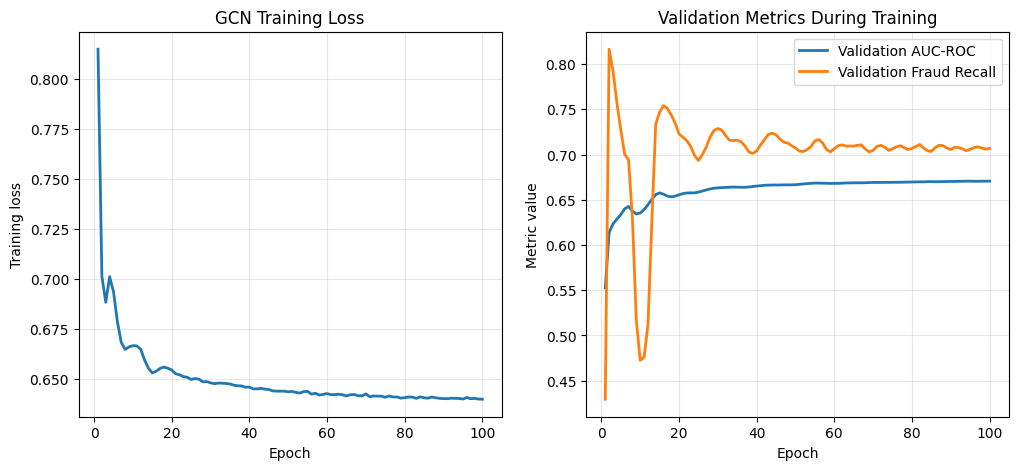

In [12]:
history_df = pd.DataFrame(history)

display(history_df.tail())

fig,ax = plt.subplots(1, 2,figsize=(12, 5))


ax[0].plot(history_df["epoch"], history_df["train_loss"], linewidth=2)
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Training loss")
ax[0].set_title("GCN Training Loss")
ax[0].grid(True, alpha=0.3)

ax[1].plot(history_df["epoch"], history_df["auc_roc"], label="Validation AUC-ROC", linewidth=2)
ax[1].plot(history_df["epoch"], history_df["fraud_recall"], label="Validation Fraud Recall", linewidth=2)
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Metric value")
ax[1].set_title("Validation Metrics During Training")
ax[1].legend()
ax[1].grid(True, alpha=0.3)
plt.show()

The training loss decreases smoothly across epochs, suggesting that the GCN is learning from the graph data.  
The validation AUC-ROC also increases gradually, reaching approximately `0.67`, which indicates an improvement in the model's ability to rank legitimate and fraudulent nodes.

The fraud recall is more unstable during the first epochs, but it later stabilizes around `0.70`, meaning that the model is able to correctly detect a relevant portion of the fraudulent nodes.



## 6. Target Fraud Node Selection

The explainability analysis is performed on a single target node, selected among the nodes labeled as fraudulent.
The selection procedure first identifies the nodes whose true label is fraud and then gives priority to those that are also correctly predicted as fraud by the trained GAT.

Among these candidates, the final target node is selected using a combined score based on the predicted fraud probability and the local graph connectivity of the node.

In [13]:
from torch_geometric.utils import degree

# All fraud nodes
fraud_nodes = (graph_data.y == 1).nonzero(as_tuple=True)[0]

in_deg = degree(graph_data.edge_index[1],num_nodes=graph_data.num_nodes)

best_pos = torch.argmax(in_deg[fraud_nodes])
node_idx = int(fraud_nodes[best_pos].item())

print("Selected target node:", node_idx)
print("In-degree:", float(in_deg[node_idx].item()))

Selected target node: 624990
In-degree: 67.0


### 6.1 Local k-hop Subgraph Extraction

To explain the prediction of the selected target node, we extract its local computation graph using a 3-hop neighborhood. This subgraph contains the nodes and edges that can contribute to the target node representation during message passing.

In [14]:
k_hop = 3

subset, sub_edge_index, mapping, edge_mask = k_hop_subgraph(
    node_idx=node_idx,
    num_hops = k_hop,
    edge_index=graph_data.edge_index,
    relabel_nodes=True,
    num_nodes=graph_data.num_nodes,
    flow="source_to_target",
)

sub_x = graph_data.x[subset]

target_sub_idx = int(mapping.item())
target_node_id = int(subset[target_sub_idx].item())

# Compute the degree of the target node inside the extracted subgraph
sub_in_degree = degree(sub_edge_index[1], num_nodes=sub_x.size(0))

sub_out_degree = degree(sub_edge_index[0], num_nodes=sub_x.size(0))


The trained GCN is evaluated on the extracted 3-hop subgraph. This step verifies that the target node is correctly mapped from the original graph to the local subgraph and checks the model prediction within this reduced computation graph.

In [15]:
# Evaluate the trained model on the extracted local subgraph
model.eval()

with torch.no_grad():
    out_sub = model(sub_x, sub_edge_index)
    probs_sub = out_sub.exp()[target_sub_idx]
    pred_sub = int(probs_sub.argmax().item())

subgraph_summary = pd.DataFrame(
    {
        "Property": [
            "Number of hops",
            "Subgraph nodes",
            "Subgraph directed edges",
            "Target local index",
            "Target original node ID",
            "Matches selected target node",
            "Target local in-degree",
            "Target local out-degree",
            "True label",
            "Predicted class",
            "P(legitimate)",
            "P(fraud)",
        ],
        "Value": [
            k_hop,
            int(sub_x.size(0)),
            int(sub_edge_index.size(1)),
            target_sub_idx,
            target_node_id,
            node_idx == target_node_id,
            int(sub_in_degree[target_sub_idx].item()),
            int(sub_out_degree[target_sub_idx].item()),
            int(graph_data.y[target_node_id].item()),
            pred_sub,
            f"{probs_sub[0].item():.4f}",
            f"{probs_sub[1].item():.4f}",
        ],
    }
)

display(subgraph_summary)

,Property,Value
0,Number of hops,3
1,Subgraph nodes,89
2,Subgraph directed edges,92
3,Target local index,23
4,Target original node ID,624990
5,Matches selected target node,True
6,Target local in-degree,67
7,Target local out-degree,0
8,True label,1
9,Predicted class,1


The extracted 3-hop subgraph contains `89` nodes and `92` directed edges.  
The selected target node is correctly mapped from the original graph to the local subgraph, with local index `23`. The target node is truly labeled as fraud and is also predicted as fraud by the trained GAT with an higher probability in respect to the legitimate class. 


# 7. GNNExplainer

The first explanation method applied to the selected fraud prediction is **GNNExplainer**.

GNNExplainer searches for the most relevant parts of the local computation graph by learning an importance mask. In this implementation, we focus on a node-level mask, meaning that each node in the extracted 3-hop subgraph receives an importance score according to its contribution to the target node prediction.

The explainer is configured for node-level multiclass classification and uses the model output in log-probability form, consistently with the GAT architecture.


In [16]:
from torch_geometric.explain import Explainer, GNNExplainer


model.eval()

gnn_explainer = Explainer(
    model=model,
    algorithm=GNNExplainer(epochs=100),
    explanation_type="model",
    node_mask_type="object",
    edge_mask_type=None,
    model_config={
        "mode": "multiclass_classification",
        "task_level": "node",
        "return_type": "log_probs",
    },
)

explanation_gnn = gnn_explainer(
    sub_x,
    sub_edge_index,
    index=target_sub_idx,
)

node_mask_gnn = explanation_gnn.node_mask.detach()

print(explanation_gnn)

Explanation(node_mask=[89, 1], prediction=[89, 2], target=[89], index=[1], x=[89, 17], edge_index=[2, 92])


GNNExplainer was configured to produce a node-level importance mask. However, for visualization and comparison with edge-based explainers, it is useful to associate an importance score also with each edge.

Since GNNExplainer does not directly return an edge mask in this configuration, each edge score is derived as the average importance of its source and target nodes. This provides an approximate edge-level representation of the node-based explanation.

In [17]:
node_scores_gnn = node_mask_gnn.view(-1).detach()
sub_edge_index = sub_edge_index.detach()

# Derive edge scores as the average importance of source and target nodes
edge_scores_gnn = (
    node_scores_gnn[sub_edge_index[0]] +
    node_scores_gnn[sub_edge_index[1]]
) / 2


After obtaining the node importance scores from GNNExplainer, the nodes in the local subgraph are ranked according to their relevance for the target prediction.

In [18]:
top_k = 10

# Rank the most important nodes according to the GNNExplainer node mask
top_k_nodes = min(top_k, node_scores_gnn.numel())
top_node_values, top_node_indices = torch.topk(node_scores_gnn, k=top_k_nodes)

top_nodes_rows = []

for rank, local_idx in enumerate(top_node_indices, start=1):
    local_idx = int(local_idx.item())
    original_node_id = int(subset[local_idx].item())
    score = float(top_node_values[rank - 1].item())
    label_value = int(graph_data.y[original_node_id].item())

    if label_value == 1:
        label = "Fraud"
    elif label_value == 0:
        label = "Legitimate"
    else:
        label = f"Unknown ({label_value})"

    top_nodes_rows.append(
        {
            "Rank": rank,
            "Local node index": local_idx,
            "Original node ID": original_node_id,
            "Importance score": round(score, 4),
            "Label": label,
            "Is target node": local_idx == target_sub_idx,
        }
    )

top_gnn_nodes_df = pd.DataFrame(top_nodes_rows)
display(top_gnn_nodes_df)


,Rank,Local node index,Original node ID,Importance score,Label,Is target node
0,1,43,1090704,0.7433,Legitimate,False
1,2,11,367206,0.7349,Legitimate,False
2,3,41,1015902,0.7210,Legitimate,False
3,4,12,421328,0.7203,Unknown (3),False
4,5,39,993698,0.7190,Legitimate,False
5,6,45,1149842,0.7183,Legitimate,False
6,7,70,1853422,0.7153,Legitimate,False
7,8,14,429140,0.7134,Legitimate,False
8,9,25,658716,0.7115,Legitimate,False
9,10,66,1766657,0.7092,Unknown (3),False


Since GNNExplainer was configured to produce node-level importance scores, edge scores are derived by averaging the importance of the source and target nodes of each edge. The edges are then ranked according to these derived scores. 

In [19]:
top_k_edges = min(10, edge_scores_gnn.numel())

# Rank the most important derived edges
top_edge_values, top_edge_indices = torch.topk(edge_scores_gnn, k=top_k_edges)

print(f"Top {top_k_edges} important edges:")

for rank, edge_idx in enumerate(top_edge_indices, start=1):
    edge_idx = int(edge_idx.item())

    source_local = int(sub_edge_index[0, edge_idx].item())
    target_local = int(sub_edge_index[1, edge_idx].item())

    source_original = int(subset[source_local].item())
    target_original = int(subset[target_local].item())

    score = float(top_edge_values[rank - 1].item())

    print(
        f"{rank}. {source_original} -> {target_original} | "
        f"score = {score:.4f}"
    )

Top 10 important edges:
1. 1853422 -> 480097 | score = 0.6660
2. 3590852 -> 1737014 | score = 0.5392
3. 1090704 -> 624990 | score = 0.5195
4. 367206 -> 624990 | score = 0.5153
5. 1015902 -> 624990 | score = 0.5083
6. 421328 -> 624990 | score = 0.5080
7. 993698 -> 624990 | score = 0.5073
8. 1149842 -> 624990 | score = 0.5070
9. 429140 -> 624990 | score = 0.5045
10. 658716 -> 624990 | score = 0.5036


###  Visualization

The top-ranked edges are visualized as a directed graph using the original node IDs. The target node is highlighted in red, while the neighboring nodes are shown in blue.

C:\Users\flavi\AppData\Local\Temp\ipykernel_12080\823076907.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


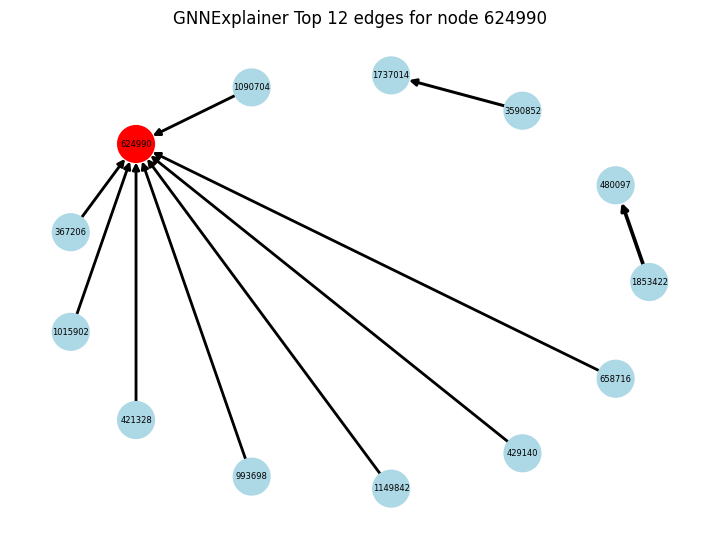

In [20]:
import networkx as nx

k_plot = 12
G = nx.DiGraph()

for i in range(min(k_plot, len(top_edge_indices))):
    edge_idx = int(top_edge_indices[i].item())

    src_local = int(sub_edge_index[0, edge_idx].item())
    dst_local = int(sub_edge_index[1, edge_idx].item())

    src = int(subset[src_local].item())
    dst = int(subset[dst_local].item())
    w = float(top_edge_values[i].item())

    G.add_edge(src, dst, weight=w)

pos = nx.circular_layout(G)  # much faster than spring_layout
widths = [max(1.0, G[u][v]["weight"] * 4) for u, v in G.edges()]
colors = ["red" if n == node_idx else "lightblue" for n in G.nodes()]

plt.figure(figsize=(7, 5))
nx.draw(
    G, pos,
    with_labels=True,
    node_color=colors,
    width=widths,
    node_size=700,
    font_size=6,
    arrows=True
)
plt.title(f"GNNExplainer Top {k_plot} edges for node {node_idx}")
plt.tight_layout()
plt.show()


Most of the important edges are incoming connections to the target node, which suggests that the GCN prediction is mainly influenced by the local neighborhood directly pointing to the fraudulent node.



# 8. GraphMaskExplainer

Unlike the previous GNNExplainer configuration, GraphMaskExplainer is used here as an edge-based explainer.  
Its goal is to identify which directed edges in the local computation graph are most relevant for preserving the model prediction.
The explainer is trained for 100 epochs and configured for node-level multiclass classification, using the GAT output in log-probability form.

In [21]:
from torch_geometric.explain import GraphMaskExplainer

model.eval()

graphmask_explainer = Explainer(
    model=model,
    algorithm=GraphMaskExplainer(
        num_layers=2,
        epochs=100,
        lr=1e-3,
    ),
    explanation_type="model",
    node_mask_type=None,
    edge_mask_type="object",
    model_config={
        "mode": "multiclass_classification",
        "task_level": "node",
        "return_type": "log_probs",
    },
)

explanation_gma = graphmask_explainer(
    sub_x,
    sub_edge_index,
    index=target_sub_idx,
)

edge_mask_gma = explanation_gma.edge_mask

if edge_mask_gma is not None:
    edge_mask_gma = edge_mask_gma.detach().cpu()


print(explanation_gma)

Train explainer for node(s) tensor([23]) with layer 1: 100%|██████████| 100/100 [00:00<00:00, 271.51it/s]
Train explainer for node(s) tensor([23]) with layer 0: 100%|██████████| 100/100 [00:00<00:00, 212.15it/s]
Explain: 100%|██████████| 2/2 [00:00<?, ?it/s]

Explanation(node_mask=[1, 17], edge_mask=[92], prediction=[89, 2], target=[89], index=[1], x=[89, 17], edge_index=[2, 92])


After applying GraphMaskExplainer, the learned edge mask is used to rank the edges in the local subgraph. Each edge receives an importance score that should indicate how relevant that connection is for the target node prediction.


In [22]:
top_k = 10

# Select the highest-scoring edges from the GraphMask edge mask
top_k_edges_gma = min(top_k, edge_mask_gma.numel())

top_edge_values_gma, top_edge_indices_gma = torch.topk(
    edge_mask_gma,
    k=top_k_edges_gma,
)

top_graphmask_edges = []

for rank, edge_idx in enumerate(top_edge_indices_gma, start=1):
    edge_idx = int(edge_idx.item())

    # Retrieve local source and target nodes
    source_local = int(sub_edge_index[0, edge_idx].item())
    target_local = int(sub_edge_index[1, edge_idx].item())

    # Map local node indices back to original graph IDs
    source_original = int(subset[source_local].item())
    target_original = int(subset[target_local].item())

    edge_score = float(top_edge_values_gma[rank - 1].item())

    top_graphmask_edges.append(
        {
            "Rank": rank,
            "Edge index": edge_idx,
            "Source local index": source_local,
            "Target local index": target_local,
            "Source original ID": source_original,
            "Target original ID": target_original,
            "Edge importance score": round(edge_score, 4),
            "Points to target node": target_local == target_sub_idx,
        }
    )

top_graphmask_edges_df = pd.DataFrame(top_graphmask_edges)

display(top_graphmask_edges_df)

,Rank,Edge index,Source local index,Target local index,Source original ID,Target original ID,Edge importance score,Points to target node
0,1,0,82,37,2986341,919734,1.0,False
1,2,79,85,74,3543729,2088154,1.0,False
2,3,2,79,23,2279179,624990,1.0,True
3,4,3,14,23,429140,624990,1.0,True
4,5,4,64,63,1678337,1660417,1.0,False
5,6,80,63,23,1660417,624990,1.0,True
6,7,6,22,23,609341,624990,1.0,True
7,8,7,66,23,1766657,624990,1.0,True
8,9,8,42,23,1031217,624990,1.0,True
9,10,9,28,23,711088,624990,1.0,True


The ranking shows that GraphMaskExplainer assigns the same maximum importance score to all displayed edges. This indicates that, in this experiment, the method does not produce a selective edge-level explanation for the target node and it is less informative.


# 9. Integrated Gradients

Unlike the previous methods, this explainer focuses on feature-level attribution rather than directly assigning importance to nodes or edges.

In this configuration, the node mask is set to `attributes`, meaning that the explainer estimates the contribution of each node feature to the fraud-class prediction. The explanation is generated for the target node in the extracted subgraph, using class `1` as the target class.

In [23]:
! pip install captum

ERROR: Could not install packages due to an OSError: [Errno 2] No such file or directory: 'e:\\wpsystem\\s-1-5-21-1495759052-2234336133-4226821522-1001\\appdata\\local\\packages\\pythonsoftwarefoundation.python.3.9_qbz5n2kfra8p0\\localcache\\local-packages\\python39\\site-packages\\torch-2.1.2.dist-info\\METADATA'


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\flavi\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [24]:
from torch_geometric.explain import Explainer, CaptumExplainer

explainer_ig = Explainer(
    model=model,
    algorithm=CaptumExplainer("IntegratedGradients"),
    explanation_type="phenomenon",
    node_mask_type="attributes",
    edge_mask_type=None,
    model_config=dict(
        mode="multiclass_classification",
        task_level="node",
        return_type="log_probs",
    ),
)
target = torch.full((sub_x.size(0),), 1, dtype=torch.long, device=sub_x.device)

explanation_ig = explainer_ig(
    x=sub_x,
    edge_index=sub_edge_index,
    index=target_sub_idx,
    target=target,  # fraud class per node
)


We perform a fidelity analysis based on the important nodes identified by the attribution mask to evaluate de explenation.

The baseline score represents the original fraud probability predicted by the GAT model. The keep test measures whether the model preserves the fraud prediction when only the important nodes are retained. The deletion test measures how much the fraud probability decreases when the important nodes are removed.



In [25]:
from utils_graph import compute_fidelity

node_mask_ig = explanation_ig.node_mask.mean(dim=-1).cpu()

base_score_ig, keep_score_ig, deletion_score_ig, important_nodes_ig = compute_fidelity(
    explanation=explanation_ig,
    model=model,
    sub_x=sub_x,
    sub_edge_index=sub_edge_index,
    target_sub_idx=target_sub_idx,
    threshold= 0,
    device=device,
 )

print(f"\n── Fidelity Integrated Gradients ───────────────────")
print(f"  P(fraud) baseline           : {base_score_ig:.4f}")
print(f"  P(fraud) keep test          : {keep_score_ig:.4f}  (Δ = {keep_score_ig - base_score_ig:+.4f})")
print(f"  P(fraud) deletion test      : {deletion_score_ig:.4f}  (Δ = {deletion_score_ig - base_score_ig:+.4f})")
print(f"  Nodes in explained subgraph : {len(important_nodes_ig)}")



── Fidelity Integrated Gradients ───────────────────
  P(fraud) baseline           : 1.0000
  P(fraud) keep test          : 1.0000  (Δ = +0.0000)
  P(fraud) deletion test      : 0.0064  (Δ = -0.9936)
  Nodes in explained subgraph : 77


The node-level attribution scores are converted into approximate edge scores.

Each edge score is computed as the average attribution of its source and target nodes. The resulting scores are then normalized between 0 and 1 to make them easier to compare and visualize.

In [26]:
# Extract and process node mask
node_mask_ig = explanation_ig.node_mask.mean(dim=-1)

# Derive edge scores from node importance
edge_scores_ig = (
    node_mask_ig[sub_edge_index[0]] + node_mask_ig[sub_edge_index[1]]
) / 2

# Normalize edge scores to [0, 1] for visualization
edge_scores_ig_norm = (
    (edge_scores_ig - edge_scores_ig.min()) /
    (edge_scores_ig.max() - edge_scores_ig.min() + 1e-8)
)

In [27]:
top_k = 10

# Select the edges with the highest normalized IG scores
top_k_edges_ig = min(top_k, edge_scores_ig_norm.numel())

top_edge_values_ig, top_edge_indices_ig = torch.topk(
    edge_scores_ig_norm,
    k=top_k_edges_ig,
)

top_ig_edges = []

for rank, edge_idx in enumerate(top_edge_indices_ig, start=1):
    edge_idx = int(edge_idx.item())

    source_local = int(sub_edge_index[0, edge_idx].item())
    target_local = int(sub_edge_index[1, edge_idx].item())

    source_original = int(subset[source_local].item())
    target_original = int(subset[target_local].item())

    normalized_score = float(top_edge_values_ig[rank - 1].item())

    top_ig_edges.append(
        {
            "Rank": rank,
            "Edge index": edge_idx,
            "Source original ID": source_original,
            "Target original ID": target_original,
            "Normalized IG score": round(normalized_score, 4),
        }
    )

top_ig_edges_df = pd.DataFrame(top_ig_edges)
display(top_ig_edges_df)

,Rank,Edge index,Source original ID,Target original ID,Normalized IG score
0,1,13,2050088,624990,1.0000
1,2,60,1311036,624990,0.9153
2,3,1,1640516,624990,0.9153
3,4,88,425451,1320838,0.9009
4,5,7,1766657,624990,0.6893
5,6,47,507320,624990,0.6854
6,7,74,1138108,624990,0.6854
7,8,27,1323850,624990,0.6728
8,9,22,90470,624990,0.6728
9,10,18,1640944,624990,0.6728


### Visualization 
The Integrated Gradients attributions are converted into edge scores by averaging the importance of the source and target nodes of each edge. 

C:\Users\flavi\AppData\Local\Temp\ipykernel_12080\3210612637.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


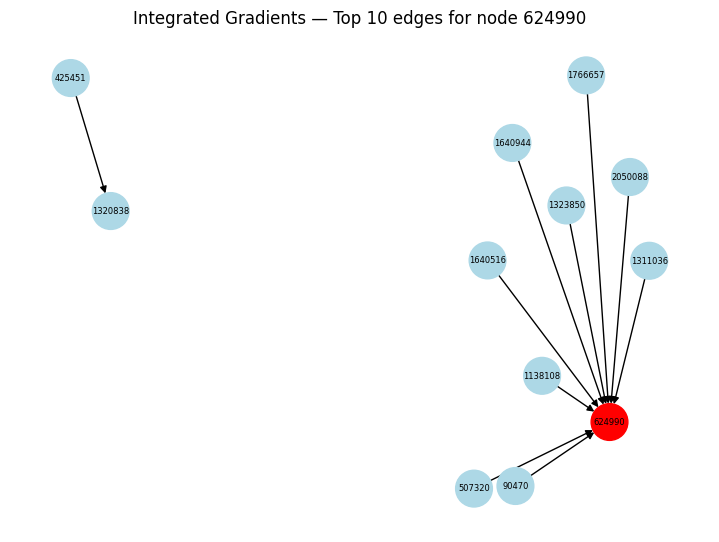

In [28]:
k_plot = 10

edge_scores_ig = (
    node_mask_ig[sub_edge_index[0].cpu()] + node_mask_ig[sub_edge_index[1].cpu()]
) / 2

top_k_idx = edge_scores_ig.argsort(descending=True)[:k_plot]
important_edges_orig = torch.stack([
    subset[sub_edge_index[0][top_k_idx]],
    subset[sub_edge_index[1][top_k_idx]],
])
edge_scores_topk = edge_scores_ig[top_k_idx]
node_idx = target_node_id

G = nx.DiGraph()
for i in range(min(k_plot, important_edges_orig.shape[1])):
    src = int(important_edges_orig[0, i].item())
    dst = int(important_edges_orig[1, i].item())
    w   = float(edge_scores_topk[i].item())
    G.add_edge(src, dst, weight=w)

pos    = nx.spring_layout(G,scale=5,seed=24)  # much faster than spring_layout
widths = [max(1.0, G[u][v]["weight"] * 4) for u, v in G.edges()]
colors = ["red" if n == node_idx else "lightblue" for n in G.nodes()]

plt.figure(figsize=(7, 5))
nx.draw(G, pos, with_labels=True, node_color=colors,
        width=widths, node_size=700, font_size=6, arrows=True)
plt.title(f"Integrated Gradients — Top {k_plot} edges for node {node_idx}")
plt.tight_layout()
plt.show()

Even though Integrated Gradients originally explains the contribution of node features, the derived structural explanation still emphasizes the incoming neighborhood of the fraudulent target node.  Two of selected edges are outside the direct target neighborhood, indicating that the GCN prediction is also influenced by some broader local connections.

# 10. CausGNN

In this step, a CausGNN-style explainer is applied to the selected local subgraph. The method learns a node-level mask that identifies which nodes are most relevant for preserving the fraud prediction of the target node.

The explainer uses a factual/counterfactual objective: the factual branch encourages the selected nodes to preserve the original prediction, while the counterfactual branch evaluates how the prediction changes when those nodes are removed. Sparsity and entropy regularization are also used to obtain a more selective and stable explanation.

In [29]:
# Import the CausGNN explainer
from CausGNN import run_causgnn_explainer

In [30]:
# This cell runs the external CausGNN implementation on the selected local subgraph.

caus_mask, caus_base, caus_pred, caus_history_df = run_causgnn_explainer(
    model=model,
    sub_x=sub_x,
    sub_edge_index=sub_edge_index,
    target_sub_idx=target_sub_idx,
    target_class=1,
    lambda_cf=0.5,
    lambda_sparsity=0.08,
    lambda_entropy=0.02,
    epochs=200,
    lr=0.01,
    device=device,
    verbose=False,
)

sorted_caus = caus_mask.argsort(descending=True)

print(f"\n{'Local idx':>10} | {'Node ID':>12} | {'Causal score':>13} | {'Label':>8}")
print("-" * 55)

for i in sorted_caus[:10]:
    local_idx = int(i.item())
    orig = int(subset[local_idx].item())
    score = float(caus_mask[local_idx].item())

    label_value = int(graph_data.y[orig].item())
    label = "FRAUD" if label_value == 1 else "legit"

    marker = " ← TARGET" if local_idx == target_sub_idx else ""

    print(f"{local_idx:>10} | {orig:>12} | {score:>13.4f} | {label:>8}{marker}")


 Local idx |      Node ID |  Causal score |    Label
-------------------------------------------------------
        23 |       624990 |        1.0000 |    FRAUD ← TARGET
        77 |      2256264 |        0.4025 |    FRAUD
        44 |      1138108 |        0.3123 |    legit
        49 |      1308009 |        0.2972 |    legit
        70 |      1853422 |        0.2843 |    legit
        87 |      3590852 |        0.2829 |    legit
        11 |       367206 |        0.2781 |    legit
        75 |      2117851 |        0.2726 |    legit
        57 |      1555327 |        0.2683 |    legit
        62 |      1640944 |        0.2645 |    legit


C:\Users\flavi\AppData\Local\Temp\ipykernel_12080\3167809698.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


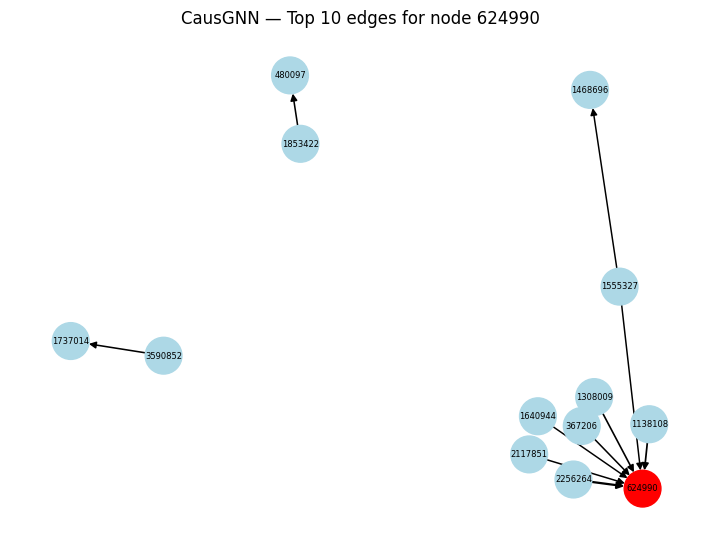

In [31]:
# This cell visualizes the top edges derived from the CausGNN node-level causal scores.

k_plot = 10

sub_edge_index_cpu = sub_edge_index.detach().cpu()

# Edge score = source node causal score
edge_scores_caus = caus_mask[sub_edge_index_cpu[0]]

top_k_idx = edge_scores_caus.argsort(descending=True)[:k_plot]

important_edges_orig = torch.stack(
    [
        subset[sub_edge_index_cpu[0][top_k_idx]],
        subset[sub_edge_index_cpu[1][top_k_idx]],
    ]
)

edge_scores_topk = edge_scores_caus[top_k_idx]

node_idx = target_node_id

G = nx.DiGraph()

for i in range(min(k_plot, important_edges_orig.shape[1])):
    src = int(important_edges_orig[0, i].item())
    dst = int(important_edges_orig[1, i].item())
    w = float(edge_scores_topk[i].item())

    G.add_edge(src, dst, weight=w)

pos = nx.spring_layout(G, scale=5, seed=18)

widths = [
    max(1.0, G[u][v]["weight"] * 4)
    for u, v in G.edges()
]

colors = [
    "red" if n == node_idx else "lightblue"
    for n in G.nodes()
]

plt.figure(figsize=(7, 5))

nx.draw(
    G,
    pos,
    with_labels=True,
    node_color=colors,
    width=widths,
    node_size=700,
    font_size=6,
    arrows=True,
)

plt.title(f"CausGNN — Top {k_plot} edges for node {node_idx}")
plt.tight_layout()
plt.show()

The explanation appears more distributed: CausGNN also selects edges located outside the immediate target neighborhood. This suggests that the GCN prediction is influenced not only by direct incoming connections to the fraudulent node, but also by additional causal patterns in the surrounding subgraph.

# 11. GECo

In this step, the GECo explainer is imported and initialized. Since GECo expects a specific model interface, the trained GAT is wrapped inside a small `ModelAdapter` class.

The adapter simply forwards the node features and edge index to the original GAT model, while keeping compatibility with the GECo API. After initialization, a first prediction is computed on the graph to verify that the explainer and the adapted model are correctly connected.

In [32]:
import os
import sys
import torch.nn as nn
from geco_explainer.geco_explainer import GECo

repo_root = os.path.abspath(".")
geco_root = os.path.join(repo_root, "geco_explainer")
if geco_root not in sys.path:
    sys.path.insert(0, geco_root)

class ModelAdapter(nn.Module):
    def __init__(self, base_model):
        super().__init__()
        self.base_model = base_model

    def forward(self, x, edge_index, batch=None):
        return self.base_model(x, edge_index)

geco = GECo(device, ModelAdapter(model))
pred, probs = geco.predict(graph_data)
print("GECo import ok, pred:", pred)

Note: to be able to use all crisp methods, you need to install some additional packages:  {'leidenalg', 'graph_tool', 'bayanpy', 'infomap', 'wurlitzer'}
Note: to be able to use all crisp methods, you need to install some additional packages:  {'ASLPAw', 'pyclustering'}
Note: to be able to use all crisp methods, you need to install some additional packages:  {'infomap', 'wurlitzer', 'leidenalg'}
GECo import ok, pred: 1


In [33]:
k_hop_geco = 3

# Extract a larger local subgraph for GECo
subset_geco, sub_edge_index_geco, mapping_geco, edge_mask_geco = k_hop_subgraph(
    node_idx=node_idx,
    num_hops=k_hop_geco,
    edge_index=graph_data.edge_index,
    relabel_nodes=True,
    num_nodes=graph_data.num_nodes,
    flow="source_to_target",
)

sub_x_geco = graph_data.x[subset_geco]
target_sub_idx_geco = int(mapping_geco.item())
target_node_id_geco = int(subset_geco[target_sub_idx_geco].item())

# Build PyG Data object expected by GECo
sub_data_geco = Data(
    x=sub_x_geco,
    edge_index=sub_edge_index_geco,
    y=graph_data.y[subset_geco],
)

# Some GECo implementations expect a batch vector
sub_data_geco.batch = torch.zeros(
    sub_x_geco.size(0),
    dtype=torch.long,
    device=device,
)

sub_data_geco = sub_data_geco.to(device)

# Test GECo prediction on the local subgraph
pred_geco, probs_geco = geco.predict(sub_data_geco)

geco_prediction_summary = pd.DataFrame(
    {
        "Property": [
            "GECo k-hop",
            "Subgraph nodes",
            "Subgraph directed edges",
            "Target local index",
            "Target original node ID",
            "Matches selected target node",
            "Target true label",
            "GECo predicted class",
            "Returned probabilities",
        ],
        "Value": [
            k_hop_geco,
            int(sub_data_geco.num_nodes),
            int(sub_data_geco.edge_index.size(1)),
            target_sub_idx_geco,
            target_node_id_geco,
            target_node_id_geco == target_node_id,
            int(graph_data.y[target_node_id_geco].item()),
            int(pred_geco),
            str(probs_geco),
        ],
    }
)

display(geco_prediction_summary)

,Property,Value
0,GECo k-hop,3
1,Subgraph nodes,89
2,Subgraph directed edges,92
3,Target local index,23
4,Target original node ID,624990
5,Matches selected target node,True
6,Target true label,1
7,GECo predicted class,1
8,Returned probabilities,[0.32294133 0.67705864]


For the GECo experiment, a larger `3`-hop subgraph was extracted around the selected target node.

The resulting local graph contains `89` nodes and `92` directed edges.   
The target node is correctly mapped from the original graph to the local subgraph, with local index 23.

The true label of the target node is fraud, and GECo predicts the same class. The returned probabilities show a higher score for the fraud class than for the legitimate class, confirming that this local subgraph is suitable for the GECo explanation step.

### Visualization

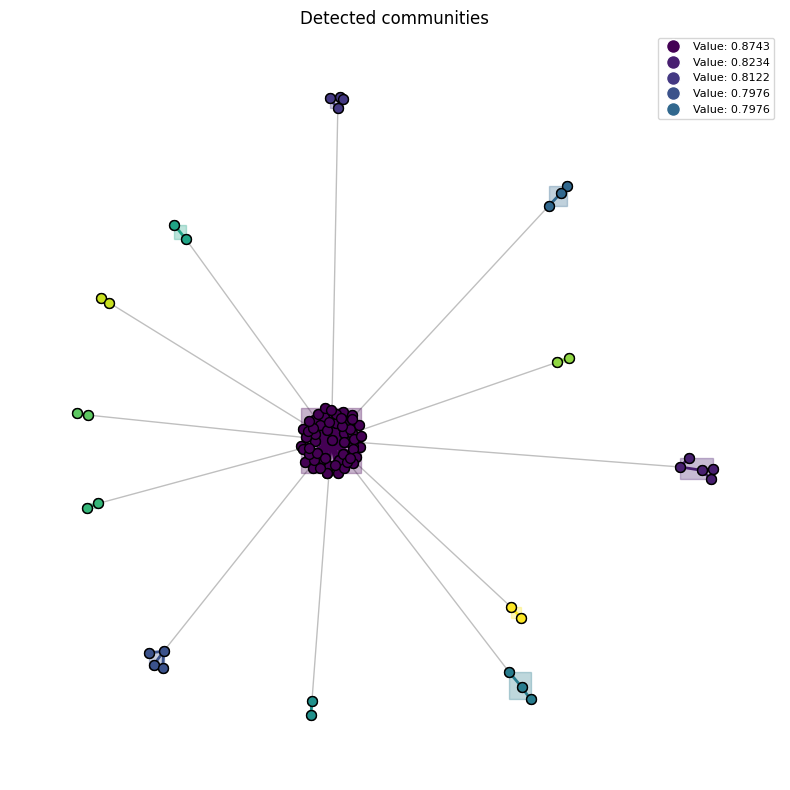

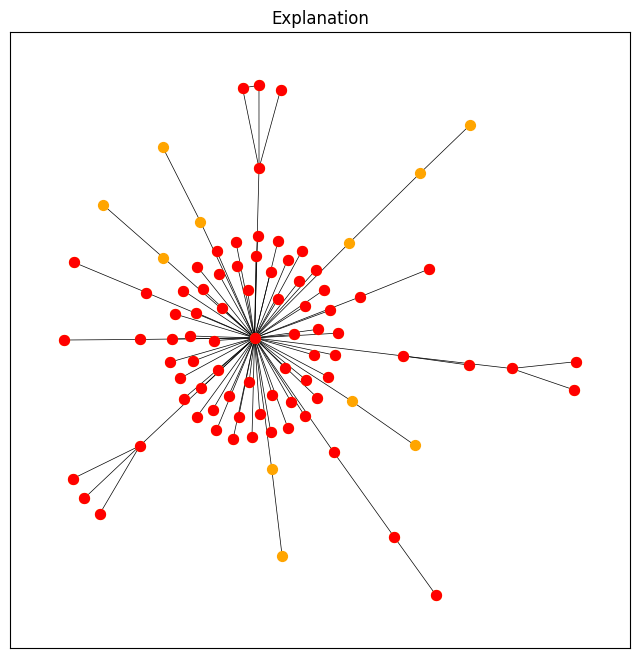

Tau 0.6194287893863825
1. Community [57, 55] (2 nodes) - Probability: 0.8743
2. Community [80, 65, 87] (3 nodes) - Probability: 0.8234
3. Community [82, 83, 67, 37, 88] (5 nodes) - Probability: 0.8122
4. Community [51, 13] (2 nodes) - Probability: 0.7976
5. Community [17, 70] (2 nodes) - Probability: 0.7976
6. Community [16, 74, 85, 86] (4 nodes) - Probability: 0.7854
7. Community [64, 84, 30, 63] (4 nodes) - Probability: 0.7009
8. Community [0, 1, 2, 3, 4, 7, 9, 10, 11, 12, 14, 15, 18, 19, 20, 21, 22, 23, 24, 25, 27, 28, 29, 31, 33, 34, 35, 36, 39, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 52, 53, 54, 56, 58, 59, 60, 61, 62, 66, 68, 69, 71, 72, 76, 77, 78] (56 nodes) - Probability: 0.6922
9. Community [81, 26, 75] (3 nodes) - Probability: 0.5399
10. Community [40, 5] (2 nodes) - Probability: 0.3724
11. Community [32, 73] (2 nodes) - Probability: 0.3724
12. Community [8, 38] (2 nodes) - Probability: 0.3707
13. Community [6, 79] (2 nodes) - Probability: 0.1136


In [34]:
graph = sub_data_geco
exp = geco.explain(graph, int(pred_sub), visualize=True, verbose=True)

The detected communities plot shows how GECo groups the local subgraph into different communities and assigns a probability score to each group. The central community is the largest and appears to contain the main neighborhood around the target node, while smaller peripheral communities represent more isolated local structures.

The explanation plot highlights the nodes and connections selected by GECo as relevant for the prediction. The target area is connected to several surrounding branches, suggesting that GECo interprets the prediction through community-level structures rather than only through individual high-scoring edges.


# 12.  GraphEXT

Unlike node-based methods, GraphEXT directly learns an edge-level mask, assigning an importance score to each connection in the subgraph.
The objective is to preserve the fraud prediction of the target node while encouraging the learned edge mask to remain compact and close to a binary selection.  
In this way, the explainer tries to identify a small set of relevant edges that are sufficient to maintain the target fraud prediction.



In [35]:
# This cell runs GraphEXT and prints the most important edges in the local subgraph.
from GraphExt import run_graphext_explainer

edge_scores_graphext, graphext_base = run_graphext_explainer(
    model=model,
    sub_x=sub_x,
    sub_edge_index=sub_edge_index,
    target_sub_idx=target_sub_idx,
    target_class=1,
    epochs=200,
    lr=0.01,
    lambda_sparsity=0.05,
    lambda_entropy=0.02,
    device=device,
    verbose=False,
)

sorted_graphext = edge_scores_graphext.argsort(descending=True)

print(f"\nGraphEXT baseline P(fraud): {graphext_base:.4f}")
print(f"\n{'Edge idx':>8} | {'Source ID':>12} | {'Target ID':>12} | {'Score':>8} | {'To target':>9}")
print("-" * 65)

for edge_idx in sorted_graphext[:10]:
    edge_idx = int(edge_idx.item())

    source_local = int(sub_edge_index[0, edge_idx].item())
    target_local = int(sub_edge_index[1, edge_idx].item())

    source_orig = int(subset[source_local].item())
    target_orig = int(subset[target_local].item())

    score = float(edge_scores_graphext[edge_idx].item())
    to_target = "YES" if target_local == target_sub_idx else "NO"

    print(
        f"{edge_idx:>8} | "
        f"{source_orig:>12} | "
        f"{target_orig:>12} | "
        f"{score:>8.4f} | "
        f"{to_target:>9}"
    )


GraphEXT baseline P(fraud): 1.0000

Edge idx |    Source ID |    Target ID |    Score | To target
-----------------------------------------------------------------
      62 |      1737014 |       624990 |   1.0000 |       YES
      66 |      1292894 |       624990 |   0.9336 |       YES
      20 |      3476829 |      1660417 |   0.8293 |        NO
      69 |       926750 |       624990 |   0.8210 |       YES
       3 |       429140 |       624990 |   0.8209 |       YES
      72 |      1540036 |       624990 |   0.8068 |       YES
      60 |      1311036 |       624990 |   0.7749 |       YES
      63 |      1579610 |       624990 |   0.7461 |       YES
      58 |      1819935 |       624990 |   0.7410 |       YES
       0 |      2986341 |       919734 |   0.7334 |        NO


### Visualization

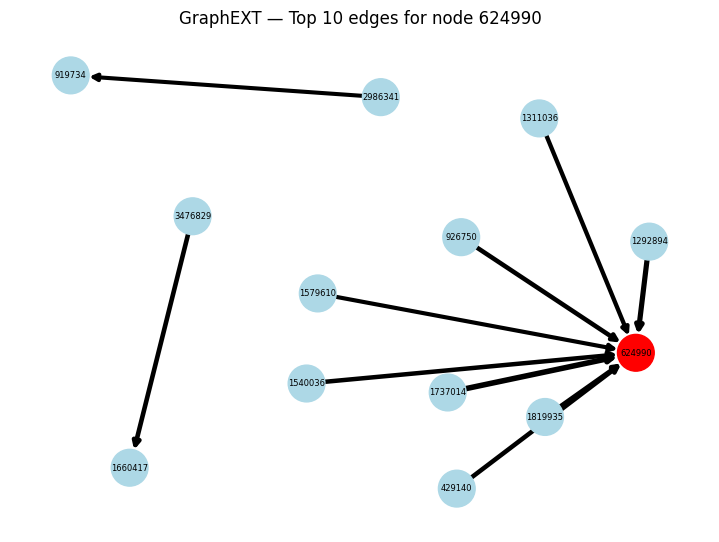

In [36]:
# This cell visualizes the top GraphEXT edges using the learned edge-level scores.

k_plot = 10

top_k_idx = edge_scores_graphext.argsort(descending=True)[:k_plot]

important_edges_orig = torch.stack(
    [
        subset[sub_edge_index[0].cpu()[top_k_idx]],
        subset[sub_edge_index[1].cpu()[top_k_idx]],
    ]
)

edge_scores_topk = edge_scores_graphext[top_k_idx]
node_idx = target_node_id

G = nx.DiGraph()

for i in range(min(k_plot, important_edges_orig.shape[1])):
    src = int(important_edges_orig[0, i].item())
    dst = int(important_edges_orig[1, i].item())
    w = float(edge_scores_topk[i].item())

    G.add_edge(src, dst, weight=w)

pos = nx.spring_layout(G, scale=5, seed=18,k=1.1)

widths = [max(1.0, G[u][v]["weight"] * 4) for u, v in G.edges()]

colors = ["red" if n == node_idx else "lightblue" for n in G.nodes()]

plt.figure(figsize=(7, 5))

nx.draw(
    G,
    pos,
    with_labels=True,
    node_color=colors,
    width=widths,
    node_size=700,
    font_size=6,
    arrows=True
)

plt.title(f"GraphEXT — Top {k_plot} edges for node {node_idx}")
plt.tight_layout()
plt.show()

Several of the highest-scoring edges point directly to the target node, confirming that the incoming neighborhood is important for the fraud prediction.

At the same time, GraphEXT also selects edges that are not directly connected to the target. This suggests that, also for the GCN model, GraphEXT captures a broader structural pattern in the local subgraph.

# 13. ORExplainer

This method learns an edge-level mask using both factual and counterfactual objectives.

The factual branch encourages the selected edges to preserve the fraud prediction, while the counterfactual branch evaluates how the prediction changes when those edges are removed. The output ranks the most important edges and indicates whether each one points directly to the target node.

In [37]:
# This cell runs ORExplainer and prints the most important edges in the local subgraph.
from OREExplainer import run_orexplainer

edge_scores_ore, ore_base = run_orexplainer(
    model=model,
    sub_x=sub_x,
    sub_edge_index=sub_edge_index,
    target_sub_idx=target_sub_idx,
    target_class=1,
    epochs=200,
    lr=0.01,
    lambda_cf=0.5,
    lambda_sparsity=0.05,
    lambda_entropy=0.02,
    device=device,
    verbose=False,
)

sorted_ore = edge_scores_ore.argsort(descending=True)

print(f"\nORExplainer baseline P(fraud): {ore_base:.4f}")
print(f"\n{'Edge idx':>8} | {'Source ID':>12} | {'Target ID':>12} | {'Score':>8} | {'To target':>9}")
print("-" * 65)

for edge_idx in sorted_ore[:10]:
    edge_idx = int(edge_idx.item())

    source_local = int(sub_edge_index[0, edge_idx].item())
    target_local = int(sub_edge_index[1, edge_idx].item())

    source_orig = int(subset[source_local].item())
    target_orig = int(subset[target_local].item())

    score = float(edge_scores_ore[edge_idx].item())
    to_target = "YES" if target_local == target_sub_idx else "NO"

    print(
        f"{edge_idx:>8} | "
        f"{source_orig:>12} | "
        f"{target_orig:>12} | "
        f"{score:>8.4f} | "
        f"{to_target:>9}"
    )


ORExplainer baseline P(fraud): 0.8688

Edge idx |    Source ID |    Target ID |    Score | To target
-----------------------------------------------------------------
      32 |       359575 |       624990 |   1.0000 |       YES
      84 |       299030 |       926750 |   0.8394 |        NO
      67 |       475280 |       624990 |   0.8266 |       YES
      33 |       838702 |       624990 |   0.7945 |       YES
      65 |      3696583 |      1768104 |   0.7819 |        NO
      79 |      3543729 |      2088154 |   0.7739 |        NO
      24 |       367206 |       624990 |   0.7347 |       YES
      22 |        90470 |       624990 |   0.7169 |       YES
      52 |      2689391 |       667636 |   0.7043 |        NO
       4 |      1678337 |      1660417 |   0.6918 |        NO


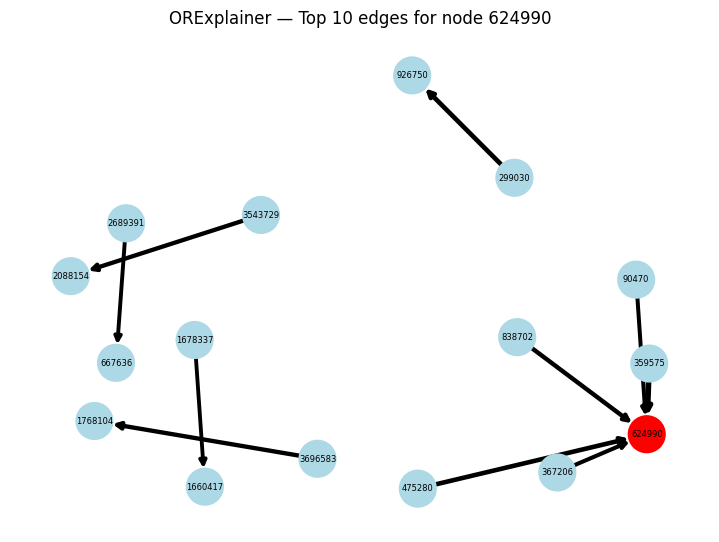

In [38]:
# This cell visualizes the top ORExplainer edges using the learned edge-level scores.

k_plot = 10

top_k_idx = edge_scores_ore.argsort(descending=True)[:k_plot]

important_edges_orig = torch.stack(
    [
        subset[sub_edge_index[0].cpu()[top_k_idx]],
        subset[sub_edge_index[1].cpu()[top_k_idx]],
    ]
)

edge_scores_topk = edge_scores_ore[top_k_idx]
node_idx = target_node_id

G = nx.DiGraph()

for i in range(min(k_plot, important_edges_orig.shape[1])):
    src = int(important_edges_orig[0, i].item())
    dst = int(important_edges_orig[1, i].item())
    w = float(edge_scores_topk[i].item())

    G.add_edge(src, dst, weight=w)

pos = nx.spring_layout(G, scale=5, seed=18,k=0.8)

widths = [
    max(1.0, G[u][v]["weight"] * 4)
    for u, v in G.edges()
]

colors = [
    "red" if n == node_idx else "lightblue"
    for n in G.nodes()
]

plt.figure(figsize=(7, 5))

nx.draw(
    G,
    pos,
    with_labels=True,
    node_color=colors,
    width=widths,
    node_size=700,
    font_size=6,
    arrows=True,
)

plt.title(f"ORExplainer — Top {k_plot} edges for node {node_idx}")
plt.tight_layout()
plt.show()

In this case, only a few of the selected edges point directly to the target node.
Compared with GNNExplainer and Integrated Gradients, ORExplainer produces a more distributed explanation. It identifies relevant structures both near the target node and in other parts of the local subgraph, suggesting that the GCN prediction is influenced by broader structural evidence rather than only by direct incoming connections.

# 14. GNNShap



In [39]:
# Clone the GNNShap repository to access the implementation of Shapley value-based explanations for GNNs.
!git clone https://github.com/HipGraph/GNNShap.git
%cd GNNShap

import os
import sys

repo_root = os.path.abspath("GNNShap")
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)


e:\GMA\GNNShap


fatal: destination path 'GNNShap' already exists and is not an empty directory.


In [40]:
from gnnshap.explainer import GNNShapExplainer

def forward_no_edge_weight(model, node_features, edge_index, node_idx, edge_weight=None):
    model.eval()
    pred = model(node_features, edge_index)
    return F.softmax(pred[node_idx, :], dim=-1)

gshap = GNNShapExplainer(
    model,
    graph_data,
    nhops=5,
    verbose=0,
    device=device,
    forward_fn=forward_no_edge_weight,
    progress_hide=True,
 )

_gnnshap.py:23:WARNING: CUDA extension not available (Ninja not installed). GNNShapSampler will not be available.


In [41]:
# This cell runs GNNShap to explain the prediction for the target node 
shap_n_samples = 10000
shap_batch_size = 1024
shape_size_limit = 3

explanation_gshap = gshap.explain(
    target_node_id,
    nsamples=shap_n_samples,
    sampler_name="SVXSampler",
    batch_size=shap_batch_size,
    solver_name="WLSSolver",
    size_lim=shape_size_limit,)

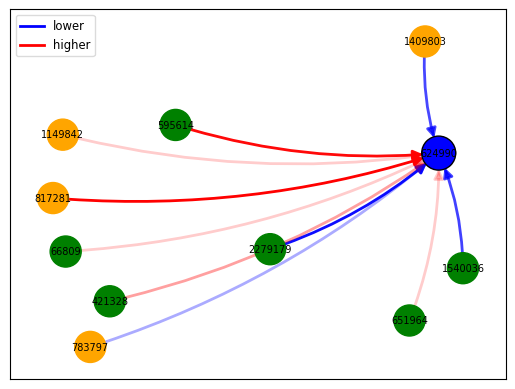

<Figure size 640x480 with 0 Axes>

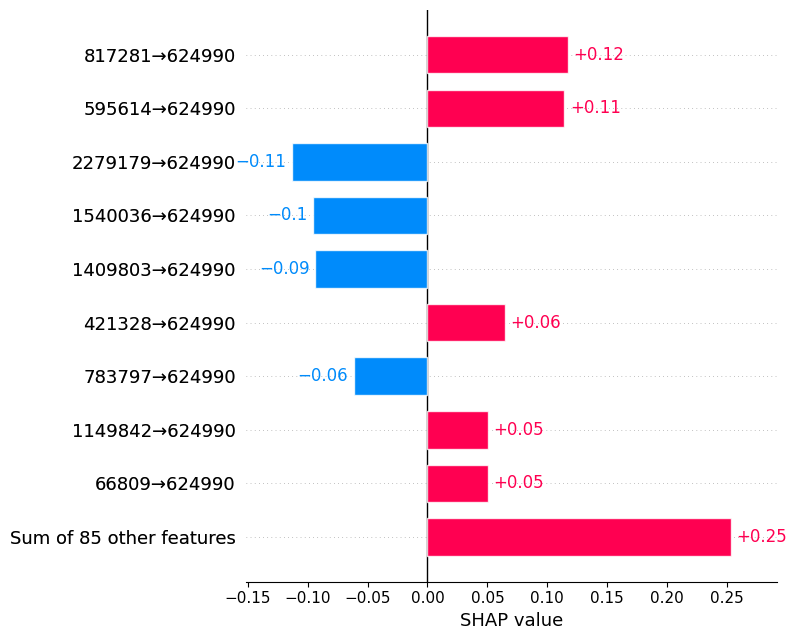

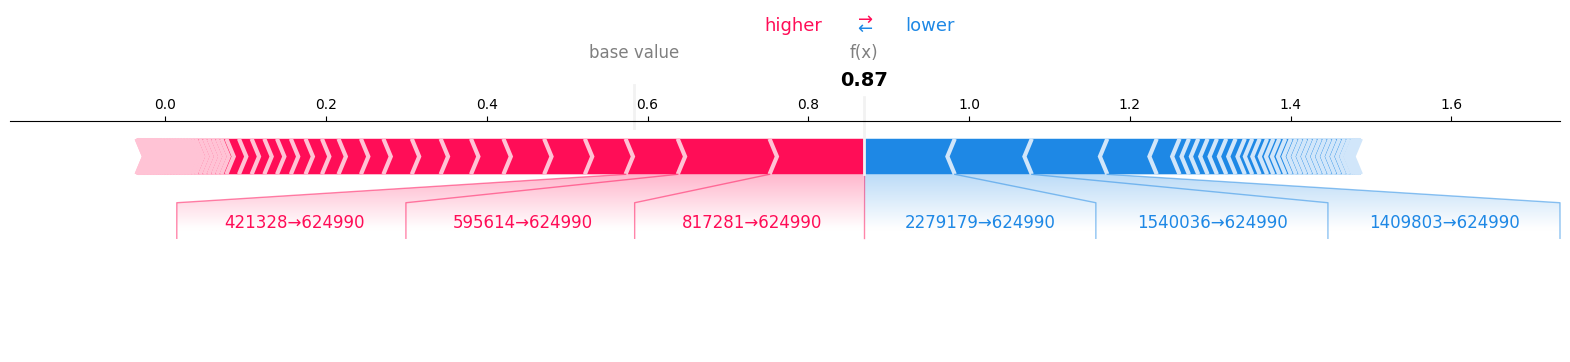

In [42]:
# Set the number of top features to visualize for GNNShap explanations
gnn_shap_top_k = 10

# Graph visualization
explanation_gshap.plot_graph(topk=gnn_shap_top_k)
plt.tight_layout()
plt.show()

# Bar plot
explanation_gshap.plot_bar(show=False)
plt.tight_layout()
plt.show()

# Force plot
explanation_gshap.plot_force(
    show_values=False,
    contrib_threshold=0.05,
)


In the graph visualization, red edges indicate connections that push the prediction toward a higher fraud score, while blue edges indicate connections that push the prediction toward a lower fraud score. The target node is strongly influenced by both positive and negative contributions from its incoming neighborhood.

The SHAP bar plot shows the individual contribution of the most relevant edges. Edges such as `817281 → 624990` and `595614 → 624990` have positive SHAP values, meaning that they increase the fraud prediction. Other edges, such as `2279179 → 624990`, `154036 → 624990`, and `1409803 → 624990`, have negative SHAP values, meaning that they reduce the fraud prediction.

The force plot indicates that pink contributions push the model output toward a higher fraud probability, while blue contributions push it lower. Overall, GNNShap shows that the final GCN prediction is the result of a balance between edges that support the fraud class and edges that oppose it.

# 15. Final Comparison
Since the explainers produce different types of outputs, all explanations are converted into edge-level scores when possible. For each method, the top-ranked edges are evaluated using a keep test and a deletion test.

This allows us to compare the explainers in terms of fidelity, selectivity, and structural focus on the target node.

In [43]:
from utils_graph import (
    compute_base_score,
    keep_top_edges_test,
    delete_top_edges_test,
    count_edges_to_target,
    normalize_scores,
)

In [44]:
final_top_k = 10
target_class = 1

# Collect available edge-level explanations

explainer_edge_scores = {}


explainer_edge_scores["GNNExplainer"] = normalize_scores(edge_scores_gnn)

explainer_edge_scores["GraphMaskExplainer"] = normalize_scores(edge_mask_gma)

explainer_edge_scores["Integrated Gradients"] = normalize_scores(edge_scores_ig_norm)

sub_edge_index_cpu = sub_edge_index.detach().cpu()
edge_scores_caus_final = caus_mask[sub_edge_index_cpu[0]]
explainer_edge_scores["CausGNN"] = normalize_scores(edge_scores_caus_final)

explainer_edge_scores["GraphEXT"] = normalize_scores(edge_scores_graphext)

explainer_edge_scores["ORExplainer"] = normalize_scores(edge_scores_ore)

In [45]:
# Final comparison

base_score = compute_base_score(
    model=model,
    x=sub_x,
    edge_index=sub_edge_index,
    target_idx=target_sub_idx,
    target_class= target_class,
)

comparison_rows = []

for explainer_name, scores in explainer_edge_scores.items():
    keep_score, top_edge_indices = keep_top_edges_test(
        edge_scores=scores,
        model=model,
        sub_x=sub_x,
        sub_edge_index=sub_edge_index,
        target_sub_idx=target_sub_idx,
        top_k= final_top_k,
        target_class= target_class,
    )

    deletion_score = delete_top_edges_test(
        edge_scores=scores,
        model=model,
        sub_x=sub_x,
        sub_edge_index=sub_edge_index,
        target_sub_idx=target_sub_idx,
        top_k= final_top_k,
        target_class= target_class,
    )

    edges_to_target = count_edges_to_target(
        edge_indices=top_edge_indices,
        sub_edge_index=sub_edge_index,
        target_sub_idx=target_sub_idx,
    )

    top_scores = scores[top_edge_indices]

    comparison_rows.append(
        {
            "Explainer": explainer_name,
            "Baseline P(fraud)": round(base_score, 4),
            "Keep test P(fraud)": round(keep_score, 4),
            "Deletion test P(fraud)": round(deletion_score, 4),
            "Keep Δ": round(keep_score - base_score, 4),
            "Deletion Δ": round(deletion_score - base_score, 4),
            "Top-k edges": final_top_k,
            "Top-k edges to target": edges_to_target,
            "Mean top-k score": round(float(top_scores.mean().item()), 4),
            "Score std": round(float(scores.std().item()), 4),
        }
    )


In [46]:
final_explainer_comparison = pd.DataFrame(comparison_rows)

final_explainer_comparison = final_explainer_comparison.sort_values(
    by=["Deletion test P(fraud)", "Keep test P(fraud)"],
    ascending=[True, False],
).reset_index(drop=True)

display(final_explainer_comparison)

,Explainer,Baseline P(fraud),Keep test P(fraud),Deletion test P(fraud),Keep Δ,Deletion Δ,Top-k edges,Top-k edges to target,Mean top-k score,Score std
0,GNNExplainer,0.8688,0.7475,0.8174,-0.1213,-0.0514,10,8,0.7451,0.2020
1,CausGNN,0.8688,0.7000,0.8432,-0.1688,-0.0256,10,7,0.7282,0.1921
2,Integrated Gradients,0.8688,0.7019,0.8446,-0.1669,-0.0242,10,9,0.7810,0.2514
3,ORExplainer,0.8688,0.6471,0.8610,-0.2217,-0.0078,10,5,0.7864,0.1882
4,GraphEXT,0.8688,0.5858,0.8709,-0.2830,0.0021,10,8,0.8207,0.1996
5,GraphMaskExplainer,0.8688,0.6245,0.8737,-0.2443,0.0049,10,7,1.0000,0.3714
